# Mountain Car

The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill. There are two versions of the mountain car domain in gymnasium: one with discrete actions and one with continuous. We will experiment with the continuous version in this one.


![Mountain Car](https://gymnasium.farama.org/_images/mountain_car_continuous.gif)

The observation is a ndarray with shape (2,) where the elements correspond to the position of the car along the x-axis and the velocity of the car.

The action is a ndarray with shape (1,), representing the directional force applied on the car. The action is clipped in the range [-1,1] and multiplied by a power of 0.0015.

A negative reward of $-0.1 * action^2$ is received at each timestep to penalise for taking actions of large magnitude. If the mountain car reaches the goal then a positive reward of +100 is added to the negative reward for that timestep.

You can read more the MountainCar Continous environment [here](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/)

#Premise

## Continous Action Spaces

It's conceptually the same as for discrete action spaces. In discrete action spaces you have a discrete distribution like the categorical distribution and you calculate the log pi probabilities using its mass function. In continuous action spaces you use a continuous distribution like the Gaussian distribution and calculate the log pi “probabilities” using its density function. Everything else is the same.

So instead of having network that outputs the parameters for a categorical distribution, you have a network that outputs parameters for (usually) a Gaussian distribution (i.e. the mean and standard deviation)

But, usually we just output the mean using a neural network, and have a separate set of learnable parameters for std (in log space) for each action. For example, if we 3 continous actions then we will have a neural network which will output the means for these actions and then separate 3 parameters which will represent the log std of these actions. We still learn these log std but they are not dependent on state. We just have a log std for each action.

Other approaches for std include:
- Having a std as output of neural network just as the mean.
- Initializing some std for all actions at start and then steadily decrease if using a std_decay hyperparameter as the training progresses.


You can use any appraoch you like.



## Reward Function

As mentioned above, s negative reward of $-0.1 * action^2$ is received at each timestep to penalise for taking actions of large magnitude. If the mountain car reaches the goal then a positive reward of +100 is added to the negative reward for that timestep.

However, you can change this reward function and write a custom one if you like and think it will make the agent learn better.

## Actor Critic Methods

Actor-Critic methods are [temporal difference (TD) learning](https://en.wikipedia.org/wiki/Temporal_difference_learning) methods that represent the policy function independent of the value function.

A policy function (or policy) returns a probability distribution over actions that the agent can take based on the given state.
A value function determines the expected return for an agent starting at a given state and acting according to a particular policy forever after.

In the Actor-Critic method, the policy is referred to as the *actor* that proposes a set of possible actions given a state, and the estimated value function is referred to as the *critic*, which evaluates actions taken by the *actor* based on the given policy.

In this tutorial, both the *Actor* and *Critic* will be represented using one neural network with two outputs.




###The Actor-Critic loss

Since we're using a hybrid Actor-Critic model, the chosen loss function is a combination of Actor and Critic losses for training:

$$L = L_{actor} + L_{critic}$$

#### The Actor loss

The Actor loss is based on [policy gradients with the Critic as a state dependent baseline](https://www.youtube.com/watch?v=EKqxumCuAAY&t=62m23s) and computed with single-sample (per-episode) estimates.

$$L_{actor} = -\sum^{T}_{t=1} \log\pi_{\theta}(a_{t} | s_{t})[G(s_{t}, a_{t})  - V^{\pi}_{\theta}(s_{t})]$$

where:
- $T$: the number of timesteps per episode, which can vary per episode
- $s_{t}$: the state at timestep $t$
- $a_{t}$: chosen action at timestep $t$ given state $s$
- $\pi_{\theta}$: is the policy (Actor) parameterized by $\theta$
- $V^{\pi}_{\theta}$: is the value function (Critic) also parameterized by $\theta$
- $G = G_{t}$: the expected return for a given state, action pair at timestep $t$

A negative term is added to the sum since the idea is to maximize the probabilities of actions yielding higher rewards by minimizing the combined loss.

<br>

##### The Advantage

The $G - V$ term in our $L_{actor}$ formulation is called the [Advantage](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html#advantage-functions), which indicates how much better an action is given a particular state over a random action selected according to the policy $\pi$ for that state.

While it's possible to exclude a baseline, this may result in high variance during training. And the nice thing about choosing the critic $V$ as a baseline is that it trained to be as close as possible to $G$, leading to a lower variance.

In addition, without the Critic, the algorithm would try to increase probabilities for actions taken on a particular state based on expected return, which may not make much of a difference if the relative probabilities between actions remain the same.

For instance, suppose that two actions for a given state would yield the same expected return. Without the Critic, the algorithm would try to raise the probability of these actions based on the objective $J$. With the Critic, it may turn out that there's no Advantage ($G - V = 0$), and thus no benefit gained in increasing the actions' probabilities and the algorithm would set the gradients to zero.

Due to the usage of this advantage function, this algorithm is also **Advantage Actor Critic (A2C)**.
<br>

#### The Critic loss

Training $V$ to be as close possible to $G$ can be set up as a regression problem with the following loss function:

$$L_{critic} = L_{\delta}(G, V^{\pi}_{\theta})$$

where $L_{\delta}$ is the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss), which is less sensitive to outliers in data than squared-error loss.


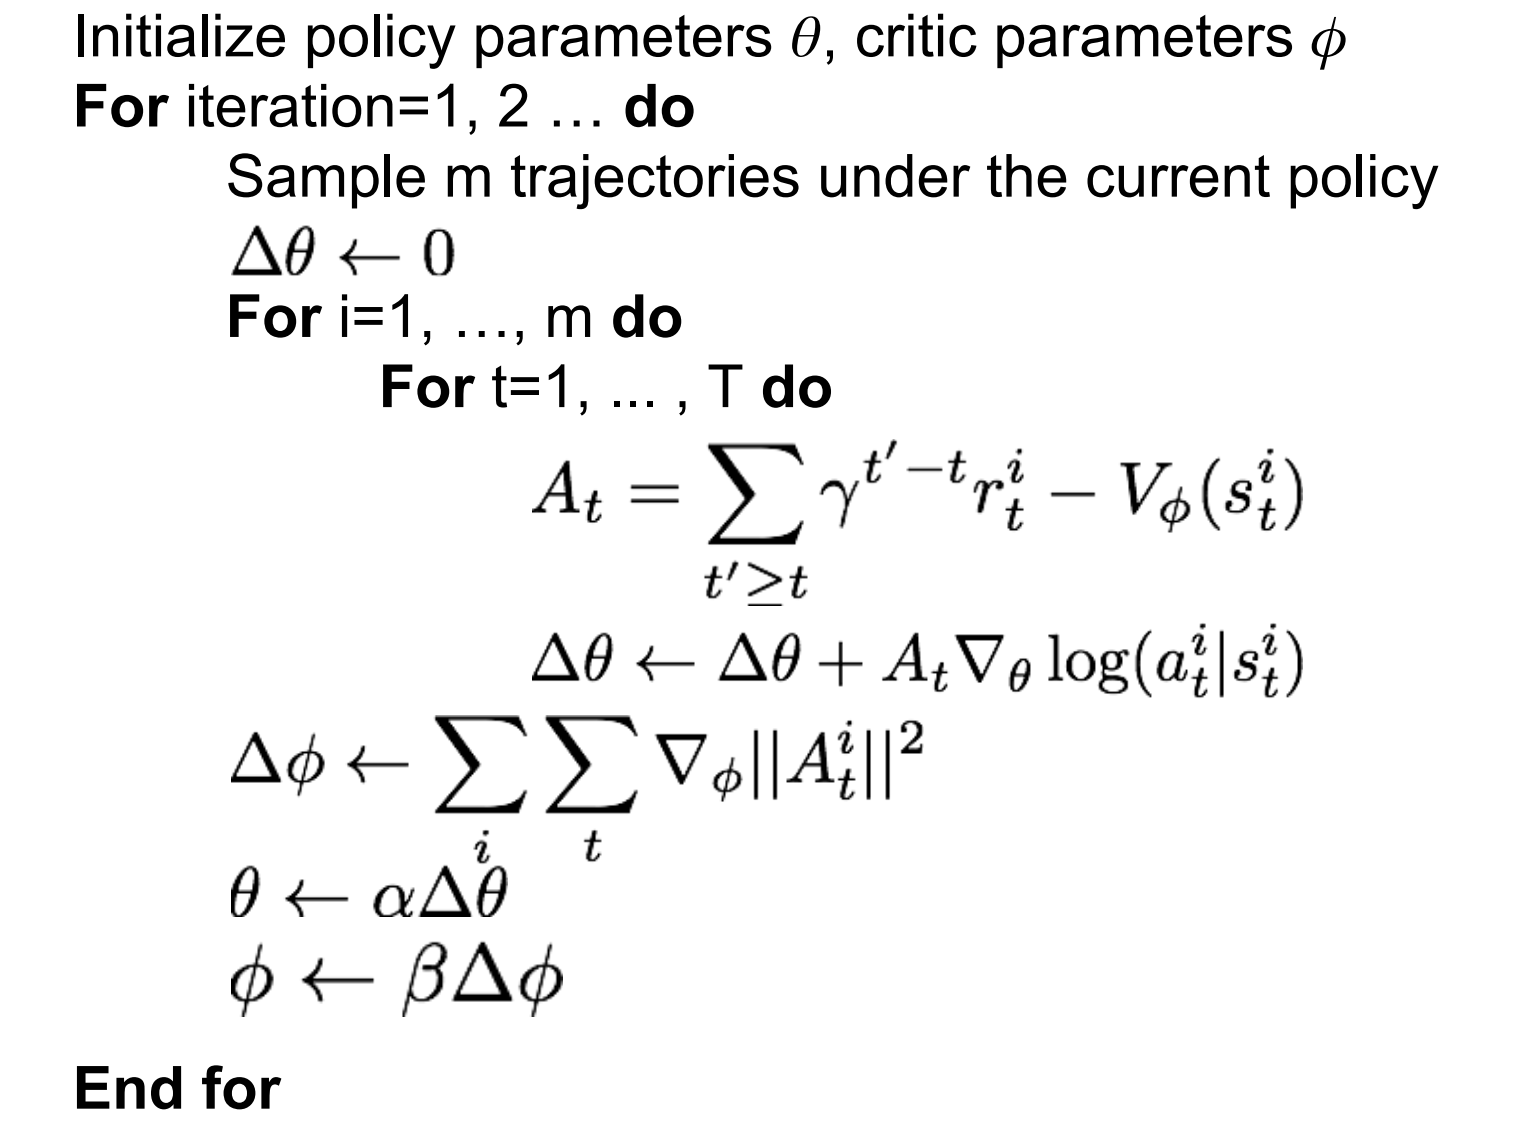

[Image Source](http://cs231n.stanford.edu/slides/2017/cs231n_2017_lecture14.pdf)

In [ ]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Normal

In [ ]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Create the environment
env = gym.make('MountainCarContinuous-v0')

#Implementation

## Network (T2)

In an Advantage Actor Critic (A2C) architecture, which is the one we are trying to implement, we can also use a single network with a shared base for both the actor (the policy) and the critic (the value function over the policy), which lowers computational costs. In this case, we use two linear layers with ReLu activation function. For the hidden layer, we use a common value of 128 neurons.

The Mountain Car environment has a continuous action space which specifies the force to apply to the car in either direction:

$$velocity_{t+1} = velocity_t + force*self.power - 0.0025*cos(3 * position_t)$$

with $force \in [-1;1]$.

Therefore we need a policy over a continuous distribution, usually a normal. The Actor head of the neural network needs to output the mean and std deviation of this distribution. The $[-1;1]$ interval suggests a hyperbolic tangent activation function for the mean, while the std is modeled as a single learnable parameter, identical for all states (more complex versions may use a different std for each state).

Regarding the critic, it needs to output a value for the value of the single action being chosen, therefore we define another head outputting this single value, which is directly used as our value function.



In [ ]:
class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(ActorCritic, self).__init__()
        self.state_size = state_size
        self.action_size = action_size

        self.fc1 = nn.Linear(state_size, hidden_size)  #A common base of 2 fully
        self.fc2 = nn.Linear(hidden_size, hidden_size) #connected layers

        #Actor
        self.actor_mean = nn.Linear(hidden_size, action_size)
        #State-independent std, we use the log at first to ensure the std is > 0
        #We initialize the log_std at -0.5, that is we select a std of exp(-0.5) approx 0.6
        self.actor_log_std = nn.Parameter(torch.full((1, action_size), -0.5))

        #Critic
        self.critic = nn.Linear(hidden_size, 1)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))

        #Actor
        mean = torch.tanh(self.actor_mean(x))
        log_std = self.actor_log_std.expand_as(mean) #In case of batch training
        std = torch.exp(log_std)                     #to match the batch dim
        dist = Normal(mean, std)

        #Critic
        value = self.critic(x)

        return dist, value

## Hyperparameters (T2, T3)

In our Actor-Critic REINFORCE implementation, we have identified 7 hyperparameters. The network learning rate, the advantage discount factor gamma, the number of episodes and max steps per episode. We also have the loss parameters, the actor loss multiplicative factor, alfa, and the critic loss one, beta.

The Mountain Car environment is not an easy one to solve, due to how the rewards are defined. The agent gets a +100 reward if it gets to the finish line, but any other action gives it a -1 reward, even if it made the car approach the objective. Therefore, until the algorithms sees the reward enough times, it's very hard for it to learn.

A first run with 5000 episodes, 500 max steps and a beta = alfa = 1.0 showed some improvements with a few successes, it took about 90 minutes to complete training. Perhaps the critic loss was getting too big for the actor loss to still properly direct the policy, therefore we lowered beta to 0.5, which slightly improved performances.

What we did then was add an entropy term, weighted by the delta parameter, to the loss hoping for the model to explore more and find the +100 reward more often, so as to nudge the weights in that direction. After 5000 episodes, the moving average is now quite stable around 0, which for this environment is not bad as such a value usually suggests the +100 reward is leveling the negative rewards at each time step, suggesting a quite stable agent capable of reaching the objective often. The final iteration uses a beta of 0.2 which offers another small performance boost.

In [ ]:
lr = 0.0006 #Network learning rate

gamma = 0.99
max_episodes = 5000
max_steps = 300 #The default truncation limit is 999

alfa = 1.0 #Actor loss multiplicative parameter
beta = 0.2 #Critic loss
delta = 0.01 #Entropy

In [ ]:
def plot_table(params):
    table_data = [[k, v] for k, v in params.items()]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')

    table = ax.table(cellText=table_data,
                     colLabels=['Hyperparameter', 'Value'],
                     loc='center',
                     cellLoc='left')

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.title("Table of Hyperparameters", fontsize=14, pad=10)
    plt.show()

params = {
    "Learning Rate": lr,
    "Discount (gamma)": gamma,
    "Episodes": max_episodes,
    "Steps": max_steps,
    "Hidden Layers": "1 shared + 1 each for the actor and critic",
    "Alfa": alfa,
    "Beta": beta,
    "Delta": delta
}

plot_table(params)

### Training (T1, T2)

The Advantage Actor Critic architecture is based on Off-policy algorithms, using Monte Carlo estimation of the policy, while at the same time approximating a state value function which, by closely following the policy, should help the gradient optimization move the policy toward an optimal one more than a simple baseline.

To implement this architecture we loop over n_episodes, for max_steps each, and save the s,a,r,s' and done flag. The temporal difference TD in this algorithm is represented by the advantage

$$A_t = \sum_{t' \geq t} γ^{t'-t}r_t - V_ϕ(a_t|s_t)$$

The loss for the actor is

$$ℒ_{actor} = - ∑_t log(π_θ(a_t|s_t)*A_t$$

while the critic loss is

$$ℒ_{critic} = ℒ_{huber}(G, V_ϕ) = \begin{cases} \frac{1}{2}(G - V_ϕ)^{2} & \text{for } |G-V_ϕ| \leq \delta, \\ \delta \cdot (|G-V_ϕ| - \frac{1}{2}\delta), & \text{otherwise.} \end{cases} = \begin{cases} \frac{1}{2}A_t^{2} & \text{for } |A_t| \leq \delta, \\ \delta \cdot (|A_t| - \frac{1}{2}\delta), & \text{otherwise.} \end{cases}$$

The advantage is therefore used both in the actor loss and the critic loss, but in different ways. Regarding the actor, we want the probabilities being updated on considering how good the trajectory was, so we use the log-prob product with the advantage. Regarding the critic, we want it to follow closely enough the policy return and therefore we use the Huber loss, which is more robust to outlier compared to the MSE thanks to the linear behavior when the advantage is larger.

The Actor-Critic architecture here implemented is very close to a standard REINFORCE. The main difference is that instead of a simpler baseline we try to use a much better approximation of the "known" value of a certain action given a state, and to do that we use a neural network.

This approach means we use a more biased estimate than an average, but it should also guarantee lower variance, more stability and possibly a faster convergence to an optimal policy.

Also, in theory, this kind of algorithm bypasses some of the limitations of a pure Monte Carlo approach by allowing for bootstrapping (estimating a value off another estimate). We could take 5 steps into an episode, estimate the rest of the rewards through the value network

$$r_t + γ V_ϕ (s_{t+1})$$

and therefore update the policy network every 5 steps instead of waiting the whole episode. This is, however, not used in our implementation.


In [ ]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.shape[0]
huber_loss = nn.SmoothL1Loss()

model = ActorCritic(state_size, action_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
scores = []

for episode in range(max_episodes):
    state, info = env.reset()
    done = False
    truncated = False
    episode_reward = 0

    #The environment switches done to True if x touches 0.45, the finish line
    states, actions, rewards, next_states, dones = [], [], [], [], []

    for step in range(max_steps):
        #The state is cast as a FloatTensor (float32), flattened and than unsqueezed,
        #which means a batch dimension is added (even though its 1) to match PyTorch expectations
        state_tensor = torch.FloatTensor(state).flatten().unsqueeze(0).to(device)

        action_dist, value = model(state_tensor) #Obtaining the distribution and value from the mode
        action = action_dist.sample()            #Sampling the action

        action_np = action.squeeze(0).cpu().numpy() #We use a batch of 1, therefore we have to squeeze the action
        #By clipping action_np to [-1;1], we make sure it's a valid value
        action_np = np.clip(action_np, env.action_space.low[0], env.action_space.high[0])

        next_state, reward, terminated, truncated, info = env.step(action_np)

        states.append(state.flatten())
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state.flatten())
        dones.append(terminated or truncated)

        #Prepare next step
        state = next_state.flatten()
        episode_reward += reward
        done = terminated or truncated

        if done:
            break

    #After each episode is complete, we cast the results into FloatTensor to
    #manage them efficiently
    states_t = torch.FloatTensor(np.array(states)).to(device)
    actions_t = torch.cat(actions).to(device)
    rewards_t = torch.FloatTensor(np.array(rewards)).to(device)
    dones_t = torch.FloatTensor(np.array(dones)).to(device)

    #Discounted returns
    returns = []
    R = 0
    for r, d in zip(reversed(rewards_t), reversed(dones_t)):
        if d:
            R = 0 #Terminal state resets return
        R = r + gamma*R
        returns.insert(0, R)
    returns = torch.FloatTensor(returns).to(device)

    #Get values for states from the critic (again, to vectorize the advantage calculations)
    action_dist, values = model(states_t)

    #Actor loss
    advantage = returns - values.squeeze(1)
    advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
    log_probs = action_dist.log_prob(actions_t).squeeze(1)
    actor_loss = -(log_probs * advantage.detach()).mean()

    #Critic loss
    critic_loss = huber_loss(values.squeeze(1), returns)

    #Final loss
    loss = alfa*actor_loss + beta*critic_loss + delta*action_dist.entropy().mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #Clipping the gradient to avoid large jumps
    optimizer.step()

    scores.append(episode_reward)

    if episode % 100 == 0:
        print(f"Episode {episode}/{n_episodes}, Reward: {episode_reward:.2f}, Loss: {loss.item():.4f}")

env.close()

Episode 0/5000, Reward: -9.98, Loss: 0.3050
Episode 100/5000, Reward: -9.74, Loss: 0.0953
Episode 200/5000, Reward: -8.55, Loss: 0.0452
Episode 300/5000, Reward: -10.08, Loss: 0.0527
Episode 400/5000, Reward: -8.06, Loss: 0.0200
Episode 500/5000, Reward: -6.48, Loss: 0.0283
Episode 600/5000, Reward: -9.47, Loss: 0.0749
Episode 700/5000, Reward: -7.09, Loss: -0.0074
Episode 800/5000, Reward: -8.03, Loss: 0.0087
Episode 900/5000, Reward: -5.53, Loss: 0.0182
Episode 1000/5000, Reward: -5.91, Loss: 0.0586
Episode 1100/5000, Reward: -5.30, Loss: -0.0187
Episode 1200/5000, Reward: -5.51, Loss: -0.0286
Episode 1300/5000, Reward: -4.92, Loss: -0.0343
Episode 1400/5000, Reward: -4.12, Loss: -0.0546
Episode 1500/5000, Reward: -4.01, Loss: 0.0393
Episode 1600/5000, Reward: -3.25, Loss: -0.0497
Episode 1700/5000, Reward: -3.58, Loss: -0.0502
Episode 1800/5000, Reward: -2.79, Loss: -0.0346
Episode 1900/5000, Reward: -3.02, Loss: -0.0604
Episode 2000/5000, Reward: -3.48, Loss: -0.0018
Episode 2100/5

### Visualization (T3)

The Actor-Critic technique shows a very nice upward trend with decreasing variance, which hits a plateau at about 0 after 5000 episodes. This clearly shows the network is learning useful weights and improving the action distribution. A 0 total episode reward, given that each step in Mountain Car gives a negative -1 reward, means that this negative input is being contrasted by the positive +100 reward the agent gets when the car reaches the finishline, at x=0.45. The results are very positive, with minimum variance.

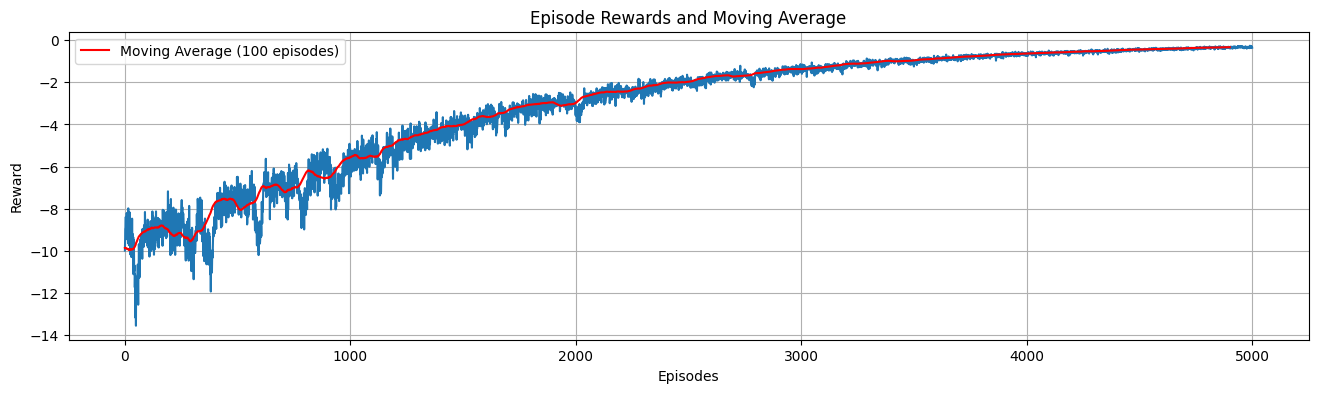

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(scores)

#Moving average
window_size = 100
if len(scores) >= window_size:
    moving_avg = np.convolve(scores, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg, color='red', label=f'Moving Average ({window_size} episodes)')
    plt.legend()

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Episode Rewards and Moving Average")
plt.grid(True)
plt.show()

In [ ]:
# For visualization
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ['SDL_VIDEODRIVER'] = 'dummy'


In [ ]:
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        candidates = [p for p in mp4list if os.path.basename(p).startswith(env_name)]
        mp4 = candidates[-1] if candidates else mp4list[-1]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name, model, max_steps=999):
    import gymnasium as gym
    env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
    env = RecordVideo(env, video_folder="video", name_prefix=env_name, episode_trigger=lambda e: True)
    state, _ = env.reset()
    done = False
    for t in range(max_steps):
        state_tensor = torch.FloatTensor(state).flatten().unsqueeze(0).to(device)
        action_dist, _ = model(state_tensor)
        action = action_dist.sample()
        action_np = action.squeeze(0).cpu().numpy()

        next_state, reward, terminated, truncated, info = env.step(action_np)
        done = terminated or truncated
        state = next_state
        if done:
            break
    env.close()

In [ ]:
show_video_of_model("MountainCarCont", model)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
show_video("MountainCarCont")